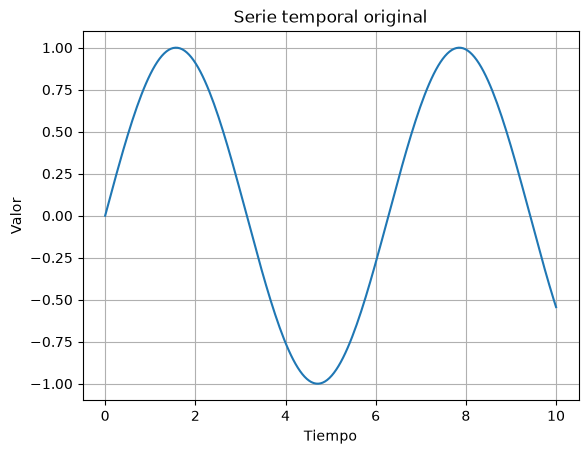

Época: 0 Error: 0.38780888463861485


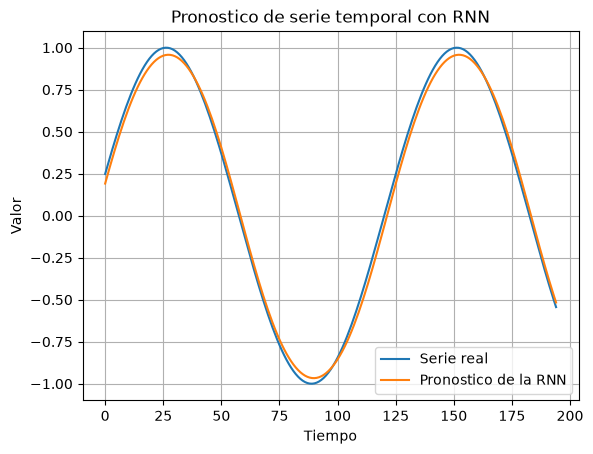

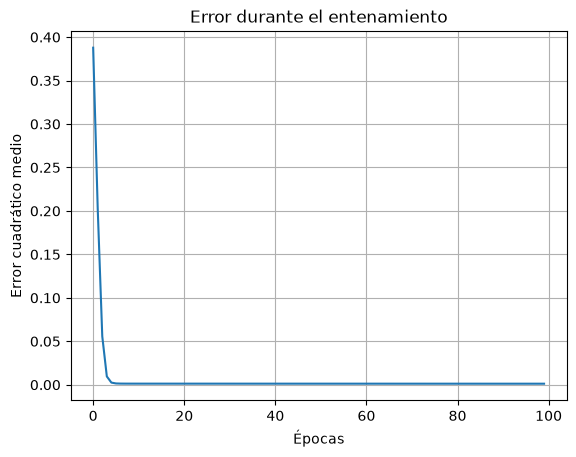

Ultimos valores utilizados:
[-0.36554384 -0.4118363  -0.45708901 -0.50118772 -0.54402111]
Pronostico del siguiente valor:
-0.557592146163452


In [1]:
import numpy as np
import matplotlib.pyplot as plt

tiempo = np.linspace(0, 10, 200)
serie = np.sin(tiempo)

plt.plot(tiempo, serie)
plt.title("Serie temporal original")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.grid(True)
plt.show()

def crear_secuencias(serie, pasos):
    X, y = [], []
    for i in range(len(serie) - pasos):
        X.append(serie[i:i + pasos])
        y.append(serie[i + pasos])
    return np.array(X), np.array(y)

pasos = 5

X, y = crear_secuencias(serie, pasos)

X = X.reshape((X.shape[0], X.shape[1], 1))
y = y.reshape(-1, 1)

def tanh(x):
    return np.tanh(x)

def derivada_tanh(x):
    return 1 - x **2

np.random.seed(42)

neuronas_entrada = 1
neuronas_ocultas = 8
neuronas_salida = 1

Wxh = np.random.randn(neuronas_entrada, neuronas_ocultas) * 0.1
Whh = np.random.randn(neuronas_ocultas, neuronas_ocultas) * 0.1
Wyh = np.random.randn(neuronas_ocultas, neuronas_salida) * 0.1

bh = np.zeros((1, neuronas_ocultas))
by = np.zeros((1, neuronas_salida))

def propagacion_adelante_mn(secuencia, Wxh, Whh, Why, bn, by):
    h = np.zeros((1, Whh.shape[0]))
    estados = []

    for t in range(len(secuencia)):
        x_t = secuencia[t].reshape(1, 1)
        h = tanh(np.dot(x_t, Wxh) + np.dot(h, Whh) + bh)
        estados.append(h)

    y_predicha = np.dot(h, Why) + by
    return y_predicha, estados
def calcular_error(y_real, y_predicha):
    return np.mean((y_real - y_predicha) ** 2)

def entrenar_rnn(X, y, Wxh, Whh, Why, bh, by, tasa_aprendizaje, epocas):
    errores = []
    for epoca in range(epocas):
        error_total = 0

    for i in range(len(X)):
        secuencia = X[i]
        valor_real = y[i].reshape(1, 1)

        y_predicha, estados = propagacion_adelante_rnn(Secuencia, Wxh, Whh, Why, bh, by)
        error = valor_real - y_predicha
        error_total = error_total + np.mean(error ** 2)

        h_final = estados[-1]

        Why = Why + tasa_aprendizaje * np.dot(h_final.T, error)
        by = by + tasa_aprendizaje * error

        ajuste_oculto = np.dot(error, Why.T) * derivada_tanh(h_final)

        ultimo_valor = secuencia[-1].reshape(1, 1)
        Wxh = Wxh + tasa_aprendizaje * np.dot(ultimo_valor.T, ajuste_oculto)
        bh = bh + tasa_aprendizaje * ajuste_oculto

        error_promedio = error_total/len(X)
        errores.append(error_promedio)
        if epoca % 100 == 0:
            print("Época:", epoca, "Error:", error_promedio)

        return Wxh, Whh, Why, bh, by, errores
tasa_aprendizaje = 0.01
epocas = 100

# Unificar el nombre de la matriz de salida
Why = Wyh.copy()

def propagacion_adelante_rnn(secuencia, Wxh, Whh, Why, bh, by):
    h = np.zeros((1, Whh.shape[0]))
    estados = []

    for t in range(len(secuencia)):
        x_t = secuencia[t].reshape(1, 1)
        h = tanh(x_t @ Wxh + h @ Whh + bh)
        estados.append(h)

    y_predicha = h @ Why + by
    return y_predicha, estados

propagacion_adelante_mn = propagacion_adelante_rnn

def entrenar_rnn(X, y, Wxh, Whh, Why, bh, by,
                 tasa_aprendizaje, epocas):
    errores = []

    for epoca in range(epocas):
        error_total = 0.0

        for i in range(len(X)):
            secuencia = X[i]
            valor_real = y[i].reshape(1, 1)

            y_predicha, estados = propagacion_adelante_rnn(
                secuencia, Wxh, Whh, Why, bh, by
            )

            error = valor_real - y_predicha
            error_total += np.mean(error ** 2)

            h_final = estados[-1]

            Why += tasa_aprendizaje * (h_final.T @ error)
            by += tasa_aprendizaje * error

            ajuste_oculto = (error @ Why.T) * derivada_tanh(h_final)
            ultimo_valor = secuencia[-1].reshape(1, 1)

            Wxh += tasa_aprendizaje * (ultimo_valor.T @ ajuste_oculto)
            bh += tasa_aprendizaje * ajuste_oculto

        error_promedio = error_total / len(X)
        errores.append(error_promedio)

        if epoca % 100 == 0:
            print("Época:", epoca, "Error:", error_promedio)

    return Wxh, Whh, Why, bh, by, errores

Wxh, Whh, Why, bh, by, errores = entrenar_rnn(
    X, y, Wxh, Whh, Why, bh, by, tasa_aprendizaje, epocas
)
pronosticos = []
for i in range(len(X)):
    y_predicha, estados = propagacion_adelante_mn(X[i], Wxh, Whh, Why, bh, by)
    pronosticos.append(y_predicha[0, 0])
pronosticos = np.array(pronosticos)

plt.plot(y, label="Serie real")
plt.plot(pronosticos, label="Pronostico de la RNN")
plt.title("Pronostico de serie temporal con RNN")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(errores)
plt.title("Error durante el entenamiento")
plt.xlabel("Épocas")
plt.ylabel("Error cuadrático medio")
plt.grid(True)
plt.show()

ultima_secuencia = serie[-pasos:].reshape(pasos, 1)

siguiente_valor, estados = propagacion_adelante_rnn(ultima_secuencia, Wxh, Whh, Why, bh, by)

print("Ultimos valores utilizados:")
print(ultima_secuencia.flatten())

print("Pronostico del siguiente valor:")
print(siguiente_valor[0, 0])


